# Ordering Sweep — Decoupling Digit Identity from Rank
Train a fresh model on each random permutation of the hierarchy.
Test whether TI performance depends on which digits occupy which rank.
Stores full position-split (winner left vs right) accuracy for every pair.

In [ ]:
import os
from pathlib import Path
os.chdir(Path("/mnt/smb/locker/abbott-locker/Luke/Mnist") / "Mnist v3")
!pwd

/mnt/smb/locker/abbott-locker/Luke/Mnist/Mnist v4


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import random
import json
from tqdm import tqdm

## Parameters

In [38]:
# Sweep
N_ORDERINGS = 20

# Training
N_ITEMS = 8
SAMPLES_PER_PAIR = 2000
DATA_SEED = 42
MODEL_SEED = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 1000
EPOCHS = 14
LR = 0.01
MOMENTUM = 0.9

## Model

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(19968, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

## Dataset Classes

In [40]:
class TransitiveTrainDatasetOrdering(Dataset):
    def __init__(self, mnist_dataset, ordering, samples_per_pair=2000, seed=42):
        self.mnist = mnist_dataset
        self.ordering = ordering
        self.samples_per_pair = samples_per_pair
        self.seed = seed

        self.digit_indices = {d: [] for d in self.ordering}
        for i in range(len(mnist_dataset)):
            _, label = mnist_dataset[i]
            if label in self.digit_indices:
                self.digit_indices[label].append(i)

        self.pairs = []
        for i in range(len(self.ordering) - 1):
            self.pairs.append((self.ordering[i], self.ordering[i + 1]))

        self._build_samples()

    def _build_samples(self):
        rng = random.Random(self.seed)
        self.samples = []
        for pair in self.pairs:
            for j in range(self.samples_per_pair):
                winner = rng.choice(self.digit_indices[pair[0]])
                loser = rng.choice(self.digit_indices[pair[1]])
                self.samples.append((pair[0], pair[1], winner, loser))

    def __getitem__(self, idx):
        sample_idx = idx // 2
        is_flipped = idx % 2
        winner_digit, loser_digit, winner_img, loser_img = self.samples[sample_idx]

        if is_flipped:
            img_left = self.mnist[loser_img][0]
            img_right = self.mnist[winner_img][0]
            label = 1
        else:
            img_left = self.mnist[winner_img][0]
            img_right = self.mnist[loser_img][0]
            label = 0

        stimulus = torch.cat([img_left, img_right], dim=-1)
        return stimulus, label

    def __len__(self):
        return len(self.samples) * 2


class TransitiveTestDatasetOrdering(Dataset):
    def __init__(self, mnist_dataset, ordering, samples_per_pair=2000, seed=42):
        self.mnist = mnist_dataset
        self.ordering = ordering
        self.samples_per_pair = samples_per_pair
        self.seed = seed

        self.digit_indices = {d: [] for d in self.ordering}
        for i in range(len(mnist_dataset)):
            _, label = mnist_dataset[i]
            if label in self.digit_indices:
                self.digit_indices[label].append(i)

        self.pairs = []
        for i in range(len(self.ordering)):
            for j in range(i + 2, len(self.ordering)):
                self.pairs.append((self.ordering[i], self.ordering[j]))

        self._build_samples()

    def _build_samples(self):
        rng = random.Random(self.seed)
        self.samples = []
        for pair in self.pairs:
            for j in range(self.samples_per_pair):
                winner = rng.choice(self.digit_indices[pair[0]])
                loser = rng.choice(self.digit_indices[pair[1]])
                self.samples.append((pair[0], pair[1], winner, loser))

    def __getitem__(self, idx):
        sample_idx = idx // 2
        is_flipped = idx % 2
        winner_digit, loser_digit, winner_img, loser_img = self.samples[sample_idx]

        if is_flipped:
            img_left = self.mnist[loser_img][0]
            img_right = self.mnist[winner_img][0]
            label = 1
        else:
            img_left = self.mnist[winner_img][0]
            img_right = self.mnist[loser_img][0]
            label = 0

        stimulus = torch.cat([img_left, img_right], dim=-1)
        return stimulus, label

    def __len__(self):
        return len(self.samples) * 2

## Helper Functions

In [41]:
def make_ordering(n=8, ordering_seed=0):
    rng = random.Random(ordering_seed)
    ordering = list(range(n))
    rng.shuffle(ordering)
    return ordering


def evaluate_accuracy(model, device, dataset, batch_size=1000):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device).long()
            pred = model(data).argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    return correct / total


def evaluate_full(model, device, dataset, ordering, batch_size=1000):
    """
    Full evaluation: by digit pair, by rank pair, by distance.
    Each split into overall, winner-left, winner-right.
    """
    model.eval()
    rank_of = {digit: rank for rank, digit in enumerate(ordering)}

    correct_by_pair = defaultdict(int)
    total_by_pair = defaultdict(int)
    correct_by_pair_left = defaultdict(int)
    total_by_pair_left = defaultdict(int)
    correct_by_pair_right = defaultdict(int)
    total_by_pair_right = defaultdict(int)

    correct_by_rank = defaultdict(int)
    total_by_rank = defaultdict(int)
    correct_by_rank_left = defaultdict(int)
    total_by_rank_left = defaultdict(int)
    correct_by_rank_right = defaultdict(int)
    total_by_rank_right = defaultdict(int)

    correct_by_distance = defaultdict(int)
    total_by_distance = defaultdict(int)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    sample_idx = 0

    with torch.no_grad():
        for stimuli, labels in loader:
            stimuli, labels = stimuli.to(device), labels.to(device)
            preds = model(stimuli).argmax(dim=1)

            for j in range(stimuli.size(0)):
                i = sample_idx + j
                sample_i = i // 2
                is_flipped = i % 2
                winner_digit, loser_digit, _, _ = dataset.samples[sample_i]

                winner_rank = rank_of[winner_digit]
                loser_rank = rank_of[loser_digit]
                distance = abs(loser_rank - winner_rank)
                is_correct = (preds[j].item() == labels[j].item())

                # By digit pair
                total_by_pair[(winner_digit, loser_digit)] += 1
                if is_correct:
                    correct_by_pair[(winner_digit, loser_digit)] += 1

                # By rank pair
                total_by_rank[(winner_rank, loser_rank)] += 1
                if is_correct:
                    correct_by_rank[(winner_rank, loser_rank)] += 1

                # By distance
                total_by_distance[distance] += 1
                if is_correct:
                    correct_by_distance[distance] += 1

                # Position split
                if is_flipped == 0:
                    total_by_pair_left[(winner_digit, loser_digit)] += 1
                    total_by_rank_left[(winner_rank, loser_rank)] += 1
                    if is_correct:
                        correct_by_pair_left[(winner_digit, loser_digit)] += 1
                        correct_by_rank_left[(winner_rank, loser_rank)] += 1
                else:
                    total_by_pair_right[(winner_digit, loser_digit)] += 1
                    total_by_rank_right[(winner_rank, loser_rank)] += 1
                    if is_correct:
                        correct_by_pair_right[(winner_digit, loser_digit)] += 1
                        correct_by_rank_right[(winner_rank, loser_rank)] += 1

            sample_idx += stimuli.size(0)

    def acc_dict(correct, total):
        return {k: correct[k] / total[k] for k in total}

    return {
        'pair_accs': acc_dict(correct_by_pair, total_by_pair),
        'pair_accs_left': acc_dict(correct_by_pair_left, total_by_pair_left),
        'pair_accs_right': acc_dict(correct_by_pair_right, total_by_pair_right),
        'rank_pair_accs': acc_dict(correct_by_rank, total_by_rank),
        'rank_pair_accs_left': acc_dict(correct_by_rank_left, total_by_rank_left),
        'rank_pair_accs_right': acc_dict(correct_by_rank_right, total_by_rank_right),
        'distance_accs': acc_dict(correct_by_distance, total_by_distance),
    }

## Load MNIST

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST('./data', train=False, transform=transform)

Using device: cuda


## Run Sweep

In [43]:
results = {}

for ordering_seed in range(N_ORDERINGS):
    ordering = make_ordering(n=N_ITEMS, ordering_seed=ordering_seed)
    print(f"\n===== Ordering {ordering_seed}/{N_ORDERINGS}: {ordering} =====")

    train_dataset = TransitiveTrainDatasetOrdering(mnist_train, ordering,
                                                   samples_per_pair=SAMPLES_PER_PAIR, seed=DATA_SEED)
    test_dataset = TransitiveTestDatasetOrdering(mnist_test, ordering,
                                                 samples_per_pair=SAMPLES_PER_PAIR, seed=DATA_SEED)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    torch.manual_seed(MODEL_SEED)
    model = Net().to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

    for epoch in tqdm(range(1, EPOCHS + 1), desc=f"  Training", unit="epoch"):
        model.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device).long()
            optimizer.zero_grad()
            output = model(data)
            loss = F.nll_loss(output, target)
            loss.backward()
            optimizer.step()

    train_acc = evaluate_accuracy(model, device, train_dataset, TEST_BATCH_SIZE)
    test_acc = evaluate_accuracy(model, device, test_dataset, TEST_BATCH_SIZE)
    test_eval = evaluate_full(model, device, test_dataset, ordering, TEST_BATCH_SIZE)
    train_eval = evaluate_full(model, device, train_dataset, ordering, TEST_BATCH_SIZE)

    print(f"  Train acc: {train_acc:.4f}")
    print(f"  Test acc:  {test_acc:.4f}")
    print(f"  By distance: {dict(sorted(test_eval['distance_accs'].items()))}")

    def serialize_eval(ev):
        return {key: {str(k): v for k, v in val.items()} for key, val in ev.items()}

    results[ordering_seed] = {
        'ordering': ordering,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test': serialize_eval(test_eval),
        'train': serialize_eval(train_eval),
    }

    del model, optimizer
    torch.cuda.empty_cache()

print("\n===== Sweep complete =====")


===== Ordering 0/20: [4, 1, 5, 2, 0, 3, 7, 6] =====


  Training: 100%|██████████| 14/14 [04:51<00:00, 20.79s/epoch]


  Train acc: 0.9996
  Test acc:  0.6139
  By distance: {2: 0.33920833333333333, 3: 0.69495, 4: 0.875875, 5: 0.3785, 6: 0.87225, 7: 0.998}

===== Ordering 1/20: [3, 6, 1, 5, 7, 0, 4, 2] =====


  Training: 100%|██████████| 14/14 [04:51<00:00, 20.84s/epoch]


  Train acc: 0.9997
  Test acc:  0.5808
  By distance: {2: 0.4459166666666667, 3: 0.4369, 4: 0.4966875, 5: 0.96425, 6: 0.73325, 7: 0.99075}

===== Ordering 2/20: [5, 3, 4, 1, 2, 6, 7, 0] =====


...

  Train acc: 0.9999
  Test acc:  0.5504
  By distance: {2: 0.5195833333333333, 3: 0.3004, 4: 0.3949375, 5: 0.8133333333333334, 6: 0.991375, 7: 0.93625}

===== Ordering 18/20: [1, 4, 6, 7, 3, 5, 0, 2] =====


  Training: 100%|██████████| 14/14 [02:55<00:00, 12.55s/epoch]


  Train acc: 0.9999
  Test acc:  0.6903
  By distance: {2: 0.5930833333333333, 3: 0.41815, 4: 0.9168125, 5: 0.9693333333333334, 6: 0.638375, 7: 0.99425}

===== Ordering 19/20: [5, 2, 3, 1, 7, 4, 6, 0] =====


  Training: 100%|██████████| 14/14 [02:55<00:00, 12.52s/epoch]


  Train acc: 0.9995
  Test acc:  0.6801
  By distance: {2: 0.9135833333333333, 3: 0.70055, 4: 0.500375, 5: 0.2715, 6: 0.74125, 7: 0.99925}

===== Sweep complete =====


## Save Results

In [44]:
results_serializable = {str(k): v for k, v in results.items()}
with open('ordering_sweep_results.json', 'w') as f:
    json.dump(results_serializable, f, indent=2)
print("Saved to ordering_sweep_results.json")

Saved to ordering_sweep_results.json


## Plot: Test Accuracy Across Orderings

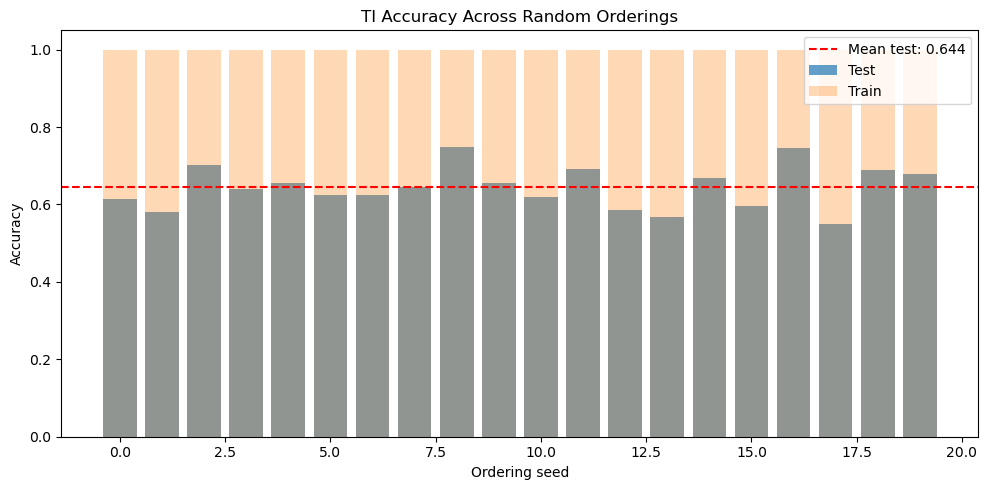

Test accuracy: mean=0.6442, std=0.0538
Train accuracy: mean=0.9997, std=0.0002


In [45]:
test_accs = [results[i]['test_acc'] for i in range(N_ORDERINGS)]
train_accs = [results[i]['train_acc'] for i in range(N_ORDERINGS)]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(N_ORDERINGS)
ax.bar(x, test_accs, alpha=0.7, label='Test')
ax.bar(x, train_accs, alpha=0.3, label='Train')
ax.axhline(y=np.mean(test_accs), color='red', linestyle='--', label=f'Mean test: {np.mean(test_accs):.3f}')
ax.set_xlabel('Ordering seed')
ax.set_ylabel('Accuracy')
ax.set_title('TI Accuracy Across Random Orderings')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('ordering_sweep_acc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Test accuracy: mean={np.mean(test_accs):.4f}, std={np.std(test_accs):.4f}")
print(f"Train accuracy: mean={np.mean(train_accs):.4f}, std={np.std(train_accs):.4f}")

## Plot: Distance Effect

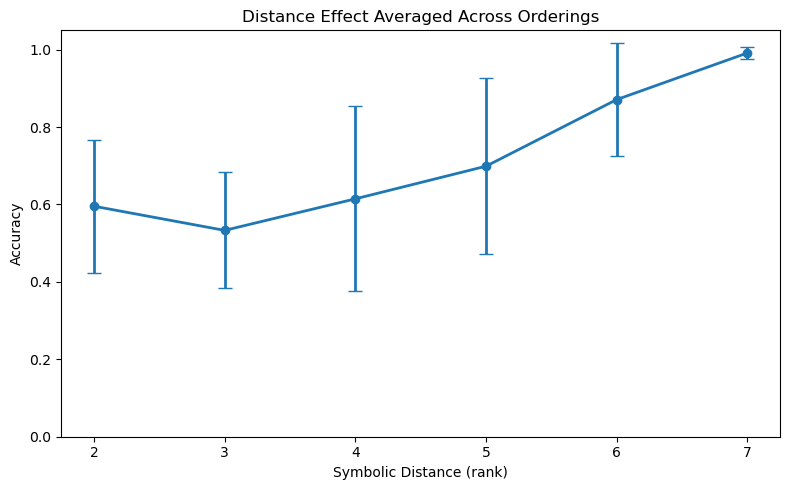

In [46]:
all_distances = set()
for i in range(N_ORDERINGS):
    all_distances.update(int(k) for k in results[i]['test']['distance_accs'].keys())
all_distances = sorted(all_distances)

distance_means = []
distance_stds = []
for d in all_distances:
    accs = [results[i]['test']['distance_accs'][str(d)] for i in range(N_ORDERINGS) if str(d) in results[i]['test']['distance_accs']]
    distance_means.append(np.mean(accs))
    distance_stds.append(np.std(accs))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(all_distances, distance_means, yerr=distance_stds, fmt='o-', capsize=5, linewidth=2)
ax.set_xlabel('Symbolic Distance (rank)')
ax.set_ylabel('Accuracy')
ax.set_title('Distance Effect Averaged Across Orderings')
ax.set_ylim(0, 1.05)
ax.set_xticks(all_distances)
plt.tight_layout()
plt.savefig('ordering_sweep_distance.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot: Per-Ordering Distance Curves

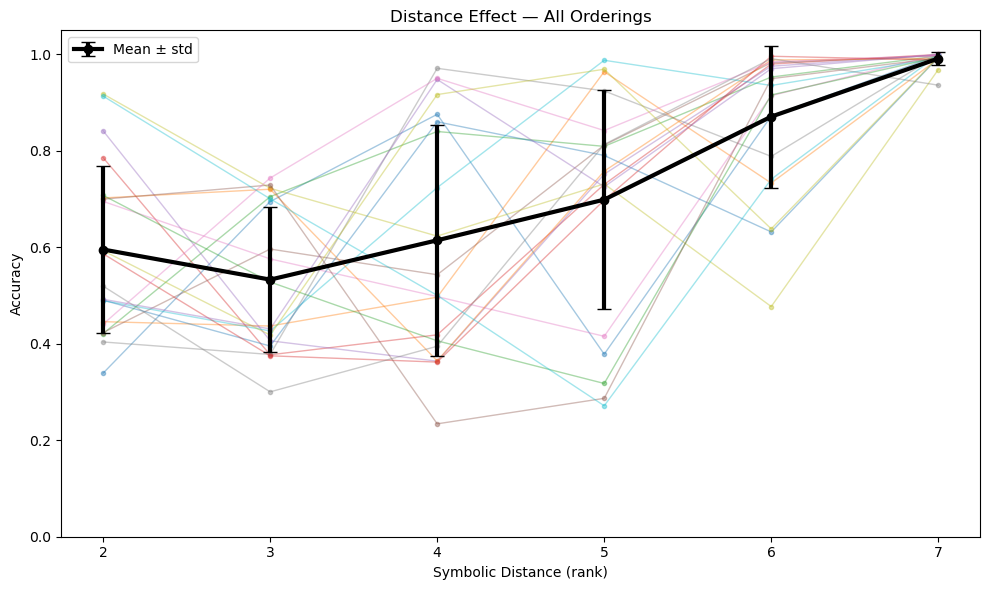

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(N_ORDERINGS):
    dist_accs = results[i]['test']['distance_accs']
    distances = sorted(int(k) for k in dist_accs.keys())
    accs = [dist_accs[str(d)] for d in distances]
    ax.plot(distances, accs, alpha=0.4, linewidth=1, marker='o', markersize=3)

ax.errorbar(all_distances, distance_means, yerr=distance_stds, fmt='o-',
            capsize=5, linewidth=3, color='black', label='Mean \u00b1 std')

ax.set_xlabel('Symbolic Distance (rank)')
ax.set_ylabel('Accuracy')
ax.set_title('Distance Effect \u2014 All Orderings')
ax.set_ylim(0, 1.05)
ax.set_xticks(all_distances)
ax.legend()
plt.tight_layout()
plt.savefig('ordering_sweep_distance_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Rank x Rank Heatmaps (Averaged Across Orderings)
Accuracy by rank position, averaged over all orderings. Removes digit identity.

In [48]:
def build_rank_matrix(results, N_ORDERINGS, N_ITEMS, key='rank_pair_accs', dataset='test'):
    acc_sums = np.zeros((N_ITEMS, N_ITEMS))
    acc_counts = np.zeros((N_ITEMS, N_ITEMS))

    for i in range(N_ORDERINGS):
        rank_accs = results[i][dataset][key]
        for pair_str, acc in rank_accs.items():
            pair = eval(pair_str)
            acc_sums[pair[0], pair[1]] += acc
            acc_counts[pair[0], pair[1]] += 1

    matrix = np.full((N_ITEMS, N_ITEMS), np.nan)
    mask = acc_counts > 0
    matrix[mask] = acc_sums[mask] / acc_counts[mask]
    return matrix


def plot_rank_heatmap(matrix, title, cmap='RdYlGn', vmin=0, vmax=1, fmt='.2f', save_path=None):
    n = matrix.shape[0]
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax, origin='upper')

    for i in range(n):
        for j in range(n):
            if not np.isnan(matrix[i, j]):
                text = f'{matrix[i, j]:{fmt}}'
                color = 'black' if 0.3 < matrix[i, j] < 0.7 else 'white'
                if cmap == 'RdBu':
                    color = 'black'
                    text = f'{matrix[i, j]:+{fmt}}'
                ax.text(j, i, text, ha='center', va='center', fontsize=9, color=color)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xlabel('Loser Rank')
    ax.set_ylabel('Winner Rank')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

### Test — Position Invariant by Rank

Saved: ordering_sweep_rank_test.png


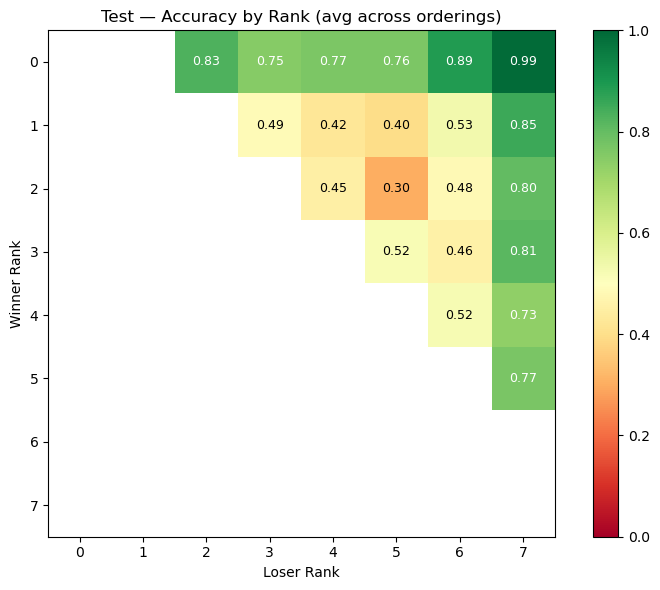

In [49]:
matrix_test = build_rank_matrix(results, N_ORDERINGS, N_ITEMS, 'rank_pair_accs', 'test')
plot_rank_heatmap(matrix_test, 'Test — Accuracy by Rank (avg across orderings)',
                  save_path='ordering_sweep_rank_test.png')

### Test — Winner on Left by Rank

Saved: ordering_sweep_rank_test_left.png


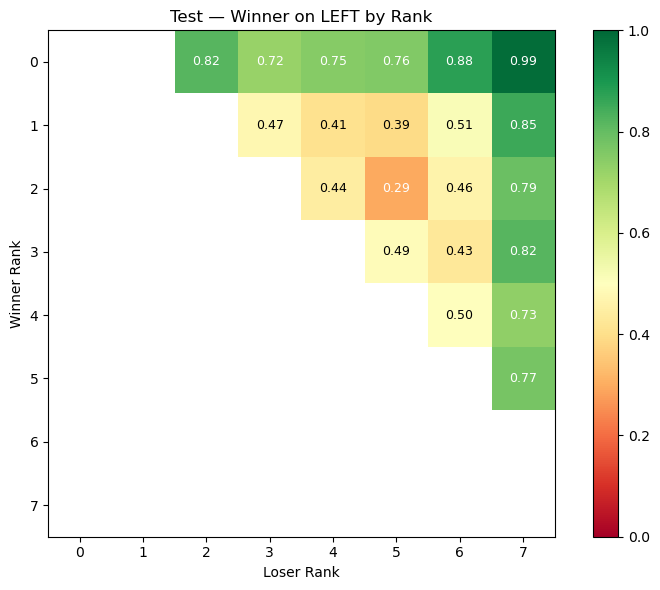

In [50]:
matrix_test_left = build_rank_matrix(results, N_ORDERINGS, N_ITEMS, 'rank_pair_accs_left', 'test')
plot_rank_heatmap(matrix_test_left, 'Test — Winner on LEFT by Rank',
                  save_path='ordering_sweep_rank_test_left.png')

### Test — Winner on Right by Rank

Saved: ordering_sweep_rank_test_right.png


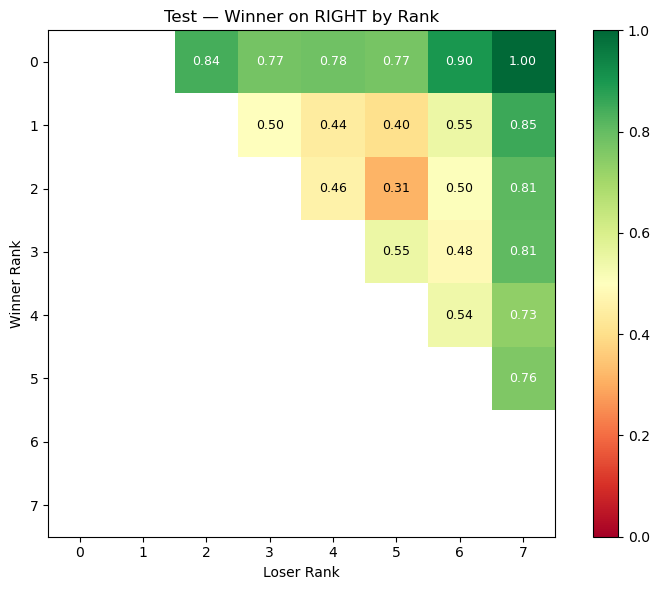

In [51]:
matrix_test_right = build_rank_matrix(results, N_ORDERINGS, N_ITEMS, 'rank_pair_accs_right', 'test')
plot_rank_heatmap(matrix_test_right, 'Test — Winner on RIGHT by Rank',
                  save_path='ordering_sweep_rank_test_right.png')

### Test — Position Bias by Rank

Saved: ordering_sweep_rank_test_bias.png


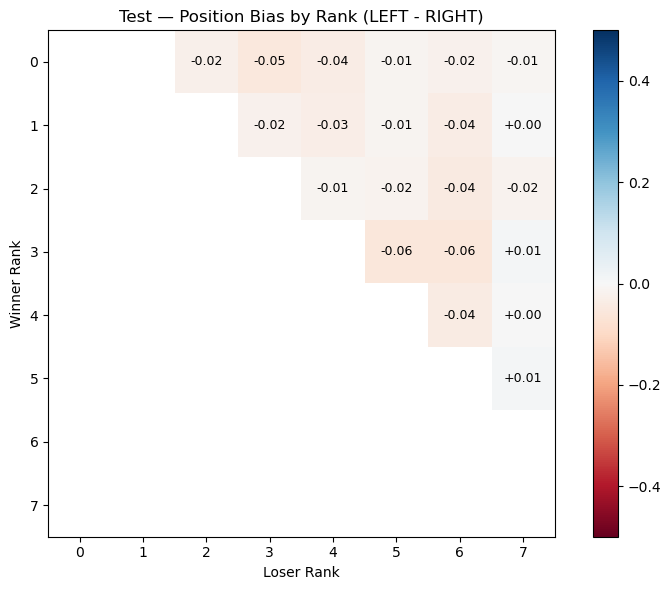

In [52]:
bias_matrix = np.full((N_ITEMS, N_ITEMS), np.nan)
mask = ~np.isnan(matrix_test_left) & ~np.isnan(matrix_test_right)
bias_matrix[mask] = matrix_test_left[mask] - matrix_test_right[mask]

plot_rank_heatmap(bias_matrix, 'Test — Position Bias by Rank (LEFT - RIGHT)',
                  cmap='RdBu', vmin=-0.5, vmax=0.5,
                  save_path='ordering_sweep_rank_test_bias.png')

### Train — Position Invariant by Rank

Saved: ordering_sweep_rank_train.png


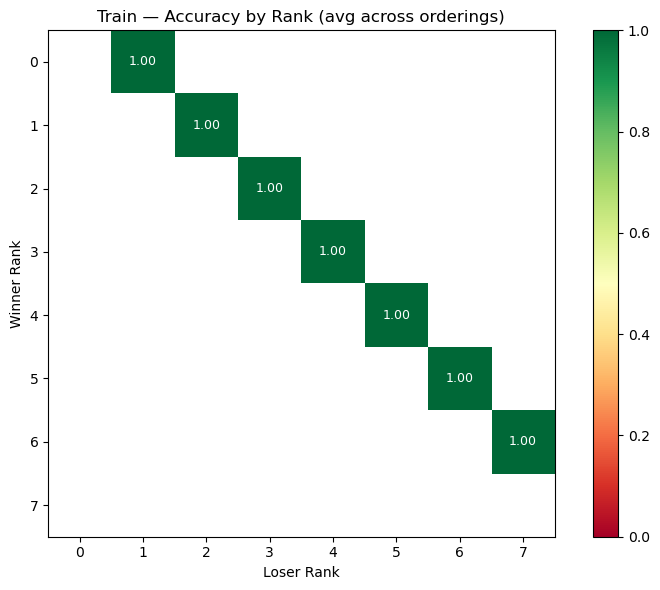

In [53]:
matrix_train = build_rank_matrix(results, N_ORDERINGS, N_ITEMS, 'rank_pair_accs', 'train')
plot_rank_heatmap(matrix_train, 'Train — Accuracy by Rank (avg across orderings)',
                  save_path='ordering_sweep_rank_train.png')

### Train — Position Bias by Rank

Saved: ordering_sweep_rank_train_bias.png


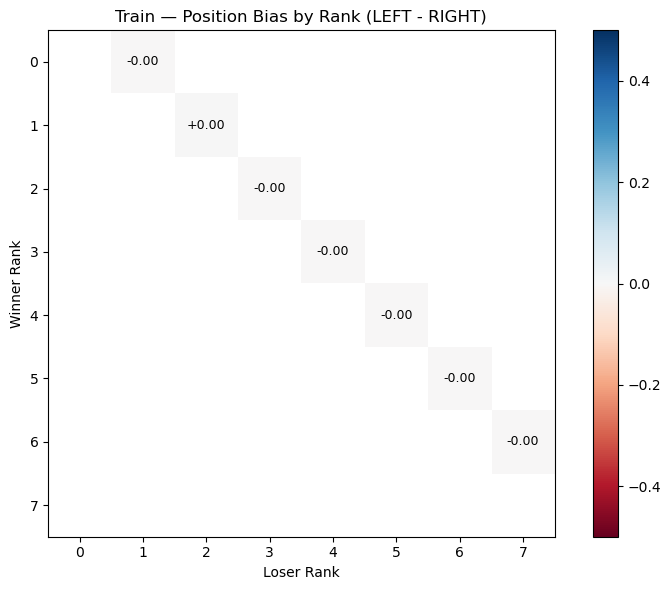

In [54]:
matrix_train_left = build_rank_matrix(results, N_ORDERINGS, N_ITEMS, 'rank_pair_accs_left', 'train')
matrix_train_right = build_rank_matrix(results, N_ORDERINGS, N_ITEMS, 'rank_pair_accs_right', 'train')

bias_matrix_train = np.full((N_ITEMS, N_ITEMS), np.nan)
mask = ~np.isnan(matrix_train_left) & ~np.isnan(matrix_train_right)
bias_matrix_train[mask] = matrix_train_left[mask] - matrix_train_right[mask]

plot_rank_heatmap(bias_matrix_train, 'Train — Position Bias by Rank (LEFT - RIGHT)',
                  cmap='RdBu', vmin=-0.5, vmax=0.5,
                  save_path='ordering_sweep_rank_train_bias.png')

## Per-Digit Performance

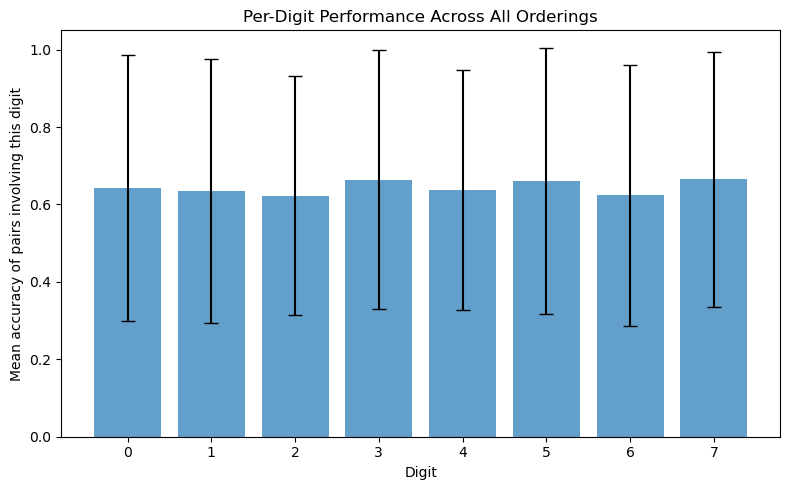

If all digits perform similarly, the network is learning relational structure.
If some digits are systematically harder, visual similarity matters.


In [55]:
digit_accs = defaultdict(list)

for i in range(N_ORDERINGS):
    pair_accs = results[i]['test']['pair_accs']
    for pair_str, acc in pair_accs.items():
        pair = eval(pair_str)
        digit_accs[pair[0]].append(acc)
        digit_accs[pair[1]].append(acc)

digits = sorted(digit_accs.keys())
means = [np.mean(digit_accs[d]) for d in digits]
stds = [np.std(digit_accs[d]) for d in digits]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(digits, means, yerr=stds, capsize=5, alpha=0.7)
ax.set_xlabel('Digit')
ax.set_ylabel('Mean accuracy of pairs involving this digit')
ax.set_title('Per-Digit Performance Across All Orderings')
ax.set_ylim(0, 1.05)
ax.set_xticks(digits)
plt.tight_layout()
plt.savefig('ordering_sweep_digits.png', dpi=150, bbox_inches='tight')
plt.show()

print("If all digits perform similarly, the network is learning relational structure.")
print("If some digits are systematically harder, visual similarity matters.")

## Summary

In [56]:
print("Ordering Sweep Summary")
print("=" * 60)
print(f"Number of orderings tested: {N_ORDERINGS}")
print(f"Epochs per ordering: {EPOCHS}")
print(f"Samples per pair: {SAMPLES_PER_PAIR}")
print(f"")
print(f"Test accuracy:  {np.mean(test_accs):.4f} \u00b1 {np.std(test_accs):.4f}")
print(f"Train accuracy: {np.mean(train_accs):.4f} \u00b1 {np.std(train_accs):.4f}")
print(f"")
print("Best ordering:")
best_idx = np.argmax(test_accs)
print(f"  Seed {best_idx}: {results[best_idx]['ordering']} -> test acc {test_accs[best_idx]:.4f}")
print("Worst ordering:")
worst_idx = np.argmin(test_accs)
print(f"  Seed {worst_idx}: {results[worst_idx]['ordering']} -> test acc {test_accs[worst_idx]:.4f}")

Ordering Sweep Summary
Number of orderings tested: 20
Epochs per ordering: 14
Samples per pair: 2000

Test accuracy:  0.6442 ± 0.0538
Train accuracy: 0.9997 ± 0.0002

Best ordering:
  Seed 8: [5, 0, 6, 4, 1, 7, 2, 3] -> test acc 0.7491
Worst ordering:
  Seed 17: [3, 1, 0, 4, 5, 2, 7, 6] -> test acc 0.5504


In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('ordering_sweep_results.json', 'r') as f:
    results_loaded = json.load(f)

# Convert string keys back to ints
results = {int(k): v for k, v in results_loaded.items()}
N_ORDERINGS = len(results)
N_ITEMS = len(results[0]['ordering'])

for i in range(N_ORDERINGS):
    rank_accs = results[i]['test']['rank_pair_accs']
    matrix = np.full((N_ITEMS, N_ITEMS), np.nan)
    for pair_str, acc in rank_accs.items():
        pair = eval(pair_str)
        matrix[pair[0], pair[1]] = acc

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    for r in range(N_ITEMS):
        for c in range(N_ITEMS):
            if not np.isnan(matrix[r, c]):
                ax.text(c, r, f'{matrix[r, c]:.2f}', ha='center', va='center', fontsize=8,
                        color='black' if 0.3 < matrix[r, c] < 0.7 else 'white')
    ax.set_xticks(range(N_ITEMS))
    ax.set_yticks(range(N_ITEMS))
    ax.set_xlabel('Loser Rank')
    ax.set_ylabel('Winner Rank')
    ax.set_title(f'Ordering {i}: {results[i]["ordering"]} — test acc {results[i]["test_acc"]:.3f}')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'ordering_sweep_results.json'

# Check Ordering

In [7]:

i = 0  # pick an ordering
ordering = results[i]['ordering']
print("Ordering:", ordering)
print("Rank 0 (strongest):", ordering[0])
print("Rank 1:", ordering[1])
print()

# Check that the digit-pair accuracy matches the rank-pair accuracy
train_pair_accs = results[i]['train']['pair_accs']
train_rank_accs = results[i]['train']['rank_pair_accs']

print("Digit pair (rank 0 vs rank 1):", f"({ordering[0]}, {ordering[1]})")
print("Digit pair acc:", train_pair_accs.get(str((ordering[0], ordering[1]))))
print("Rank pair (0, 1) acc:", train_rank_accs.get(str((0, 1))))

Ordering: [4, 1, 5, 2, 0, 3, 7, 6]
Rank 0 (strongest): 4
Rank 1: 1

Digit pair (rank 0 vs rank 1): (4, 1)
Digit pair acc: 0.9995
Rank pair (0, 1) acc: 0.9995
